In [1]:
import pandas as pd
data = pd.read_csv ("REU end use data.csv")
data.head()

,Location ID,Start Time,End Time,Event,Volume (gal),Duration (min)
0,110510,2024-11-13 15:00:55.000,2024-11-13 15:01:00.000,FAUCET,0.034632,0.083333
1,110510,2024-11-13 16:58:55.000,2024-11-13 16:59:00.000,FAUCET,0.034632,0.083333
2,110510,2024-11-13 18:03:55.000,2024-11-13 18:04:00.000,FAUCET,0.034632,0.083333
3,110510,2024-11-13 19:36:35.000,2024-11-13 19:36:40.000,FAUCET,0.034632,0.083333
4,110510,2024-11-13 21:35:30.000,2024-11-13 21:35:35.000,FAUCET,0.034632,0.083333


In [2]:
unique_enduses = data['Event'].unique()
print(unique_enduses)

<StringArray>
[        'FAUCET',         'SHOWER',         'TOILET', 'CLOTHES_WASHER',
         'INDOOR',     'IRRIGATION',           'LEAK',    'DISH_WASHER',
        'OUTDOOR',       'SOFTENER',            'TUB']
Length: 11, dtype: str


In [3]:
data['avgflow (gal/min)'] = data['Volume (gal)'] / data['Duration (min)']

In [4]:
data.head()

,Location ID,Start Time,End Time,Event,Volume (gal),Duration (min),avgflow (gal/min)
0,110510,2024-11-13 15:00:55.000,2024-11-13 15:01:00.000,FAUCET,0.034632,0.083333,0.415584
1,110510,2024-11-13 16:58:55.000,2024-11-13 16:59:00.000,FAUCET,0.034632,0.083333,0.415584
2,110510,2024-11-13 18:03:55.000,2024-11-13 18:04:00.000,FAUCET,0.034632,0.083333,0.415584
3,110510,2024-11-13 19:36:35.000,2024-11-13 19:36:40.000,FAUCET,0.034632,0.083333,0.415584
4,110510,2024-11-13 21:35:30.000,2024-11-13 21:35:35.000,FAUCET,0.034632,0.083333,0.415584


In [5]:
X, y = (data[['avgflow (gal/min)', 'Duration (min)']], data['Event'])

In [6]:
X

,avgflow (gal/min),Duration (min)
0,0.415584,0.083333
1,0.415584,0.083333
2,0.415584,0.083333
3,0.415584,0.083333
4,0.415584,0.083333
...,...,...
9526024,0.871524,20.000000
9526025,0.879264,20.000000
9526026,0.933444,20.000000
9526027,0.806508,20.000000


In [7]:
y


0              FAUCET
1              FAUCET
2              FAUCET
3              FAUCET
4              FAUCET
              ...    
9526024    IRRIGATION
9526025    IRRIGATION
9526026    IRRIGATION
9526027    IRRIGATION
9526028    IRRIGATION
Name: Event, Length: 9526029, dtype: str

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=125 #so each time we run the code, we get the same split
)

In [19]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()       
model.fit(X_train, y_train)

predicted = model.predict(X_test)       
print ("Accuracy of Naive Bayes Classifier on test set: ", model.score(X_test, y_test))

Accuracy of Naive Bayes Classifier on test set:  0.9313981785156461


In [9]:
data2 = pd.read_csv (r"C:\Users\frjack2\OneDrive - University of Illinois - Urbana\RESEARCH\Code\classification script\testing zahras code\Synthetic_data_12k_balanced.csv")

In [11]:
data2.head()

,Unnamed: 0.1,Unnamed: 0,duration,avgflow,label
0,0,1511,31,1.373866,f
1,1,286,33,1.475302,f
2,2,1390,58,1.088408,f
3,3,1453,40,1.748837,f
4,4,1928,11,0.493561,f


In [17]:
X2, y2 = (data2[['avgflow', 'duration']], data2['label'])
y2

0        f
1        f
2        f
3        f
4        f
        ..
11995    w
11996    w
11997    w
11998    w
11999    w
Name: label, Length: 12000, dtype: str

In [ ]:
%%time

# ============================================================
# 2. NAIVE BAYES WITH CROSS-VALIDATION: DATA2 (Synthetic Data balanced)
# ============================================================

cv_data2 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=125
)

naive_bayes_parameters_data2 = {
    "var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}

naive_bayes_grid_data2 = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=naive_bayes_parameters_data2,
    cv=cv_data2,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

# Train using all data2 through cross-validation
naive_bayes_grid_data2.fit(X2, y2)

print("DATA2")
print(
    "Best cross-validation balanced accuracy = "
    + str(naive_bayes_grid_data2.best_score_)
)
print(
    "Best parameters = "
    + str(naive_bayes_grid_data2.best_params_)
)

# Out-of-fold predictions for every data2 row
data2_cv_predictions = cross_val_predict(
    naive_bayes_grid_data2.best_estimator_,
    X2,
    y2,
    cv=cv_data2,
    method="predict",
    n_jobs=-1
)

# Overall performance
data2_accuracy = accuracy_score(y2, data2_cv_predictions)
data2_balanced_accuracy = balanced_accuracy_score(
    y2,
    data2_cv_predictions
)

print(f"\nOverall accuracy: {data2_accuracy:.4f}")
print(f"Balanced accuracy: {data2_balanced_accuracy:.4f}")

# Per-end-use performance
data2_report = classification_report(
    y2,
    data2_cv_predictions,
    output_dict=True,
    zero_division=0
)

data2_metrics_by_class = pd.DataFrame(data2_report).T

data2_metrics_by_class = data2_metrics_by_class.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

print("\nMetrics for each data2 end use:")
display(data2_metrics_by_class.round(4))

# Final model trained on all data2 using the best parameter
final_naive_bayes_data2 = naive_bayes_grid_data2.best_estimator_
final_naive_bayes_data2.fit(X2, y2)

DATA2
Best cross-validation balanced accuracy = 0.9080833333333332
Best parameters = {'var_smoothing': 1e-09}

Overall accuracy: 0.9081
Balanced accuracy: 0.9081

Metrics for each data2 end use:


,Precision,Recall,F1 Score,Number of Samples
d,0.9172,0.9695,0.9426,2000.0000
f,0.8467,0.7680,0.8055,2000.0000
r,0.8613,0.9750,0.9146,2000.0000
s,0.9985,1.0000,0.9993,2000.0000
t,0.8621,0.7880,0.8234,2000.0000
w,0.9590,0.9480,0.9535,2000.0000
accuracy,0.9081,0.9081,0.9081,0.9081
macro avg,0.9075,0.9081,0.9065,12000.0000
weighted avg,0.9075,0.9081,0.9065,12000.0000


CPU times: total: 766 ms
Wall time: 8.51 s


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.33, random_state=125 #so each time we run the code, we get the same split
)
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()       
model.fit(X_train2, y_train2)

predicted = model.predict(X_test2)       
print ("Accuracy of Naive Bayes Classifier on test set 2: ", model.score(X_test2, y_test2))

Accuracy of Naive Bayes Classifier on test set 2:  0.908080808080808


clf3 = GridSearchCV(RandomForestClassifier(n_jobs = -1), {
    'n_estimators' : [10, 50, 100, 200], #why these specific three selections 
     'criterion' : ['gini', 'entropy'], #are there other criterion except gini and when do we use them
     'max_depth' : [5, 10, 15, 20]
}, cv = 10, return_train_score=True)

 #change to NEW data here #hope village daya or whatever data 

#change your data resolution here 
# #checks available input parameter keys as a test case
# clf.get_params().keys()
#calls the fit function to actually do the thing on the training data
clf3.fit(X,y) #Train on training data 

print("Total Accuracy = " + str(clf3.best_score_))
print("Best Params = " + str(clf3.best_params_))

In [ ]:
#confusion_matrix = pd.crosstab(y_test, predicted, rownames=['Actual'], colnames=['Predicted'])

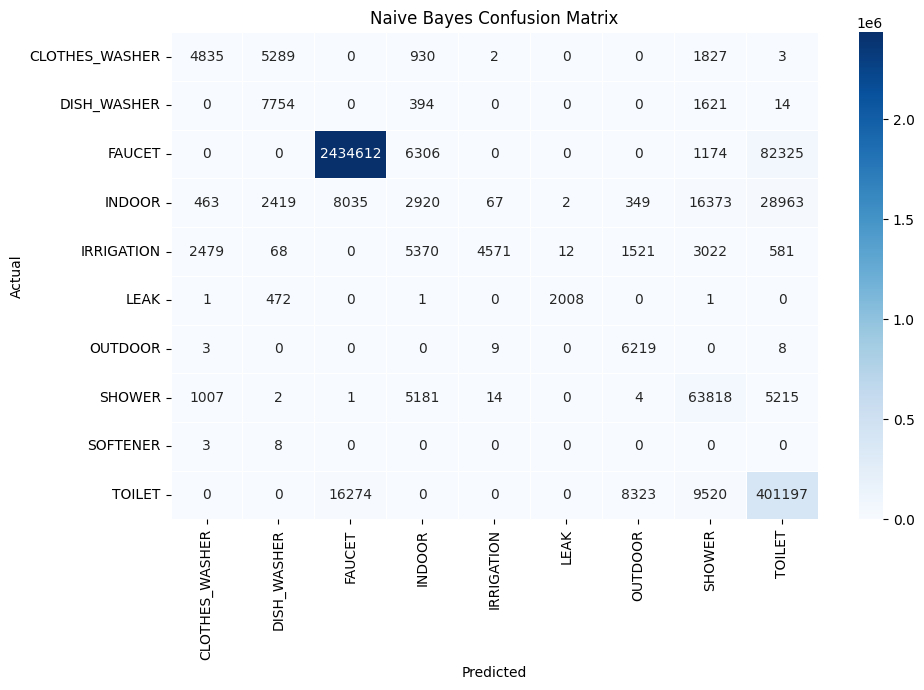

In [22]:
confusion_matrix = pd.crosstab(
    y_test,
    predicted,
    rownames=["Actual"],
    colnames=["Predicted"]
)

plt.figure(figsize=(10, 7))

sn.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
print (confusion_matrix)

Predicted       CLOTHES_WASHER  DISH_WASHER   FAUCET  INDOOR  IRRIGATION  \
Actual                                                                     
CLOTHES_WASHER            4835         5289        0     930           2   
DISH_WASHER                  0         7754        0     394           0   
FAUCET                       0            0  2434612    6306           0   
INDOOR                     463         2419     8035    2920          67   
IRRIGATION                2479           68        0    5370        4571   
LEAK                         1          472        0       1           0   
OUTDOOR                      3            0        0       0           9   
SHOWER                    1007            2        1    5181          14   
SOFTENER                     3            8        0       0           0   
TOILET                       0            0    16274       0           0   

Predicted       LEAK  OUTDOOR  SHOWER  TOILET  
Actual                                 

In [25]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# Fit the classifier using the same feature names as X_test2
model = GaussianNB()
model.fit(X_train2, y_train2)

y_pred = model.predict(X_test2)

# Overall metrics
print(f"Overall accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test2, y_pred):.4f}")

# Per-class metrics
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

metrics_by_class = pd.DataFrame(report).T

# Keep only actual end-use classes
class_labels = sorted(set(y_test2))
metrics_by_class = metrics_by_class.loc[
    [str(label) for label in class_labels]
]


metrics_by_class = metrics_by_class.rename(columns={
    "precision": "Precision",
    "recall": "Recall / Class Accuracy",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

display(metrics_by_class)

Overall accuracy: 0.9081
Balanced accuracy: 0.9072


,Precision,Recall / Class Accuracy,F1 Score,Number of Samples
d,0.900433,0.971963,0.934831,642.0
f,0.855670,0.757991,0.803874,657.0
r,0.848522,0.991367,0.914399,695.0
s,0.996918,1.000000,0.998457,647.0
t,0.882042,0.776744,0.826051,645.0
w,0.971037,0.945104,0.957895,674.0


In [28]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)
import pandas as pd

# Fit the initial Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Overall metrics
print(f"Overall accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

# Per-end-use metrics
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

metrics_by_class = pd.DataFrame(report).T

# Rename the metric columns
metrics_by_class = metrics_by_class.rename(columns={
    "precision": "Precision",
    "recall": "Recall / Class Accuracy",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

# Display numeric metrics for each end use
display(metrics_by_class.round(4))

Overall accuracy: 0.9314
Balanced accuracy: 0.6016


,Precision,Recall / Class Accuracy,F1 Score,Number of Samples
CLOTHES_WASHER,0.5500,0.3752,0.4461,1.288600e+04
DISH_WASHER,0.4843,0.7926,0.6012,9.783000e+03
FAUCET,0.9901,0.9644,0.9771,2.524417e+06
INDOOR,0.1384,0.0490,0.0724,5.959100e+04
IRRIGATION,0.9803,0.2594,0.4102,1.762400e+04
LEAK,0.9931,0.8087,0.8915,2.483000e+03
OUTDOOR,0.3788,0.9968,0.5490,6.239000e+03
SHOWER,0.6555,0.8482,0.7395,7.524200e+04
SOFTENER,0.0000,0.0000,0.0000,1.100000e+01
TOILET,0.7741,0.9216,0.8414,4.353140e+05


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)
import pandas as pd

# Keep the same class proportions in train and test
# Remove classes with fewer than two samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index

mask = y.isin(valid_classes)
X_split = X.loc[mask]
y_split = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_split,
    y_split,
    test_size=0.33,
    random_state=125,
    stratify=y_split
)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Overall metrics
print(f"Overall accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

# Individual end-use metrics
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

metrics_by_class = pd.DataFrame(report).T

metrics_by_class = metrics_by_class.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

display(metrics_by_class.round(4))

Overall accuracy: 0.9315
Balanced accuracy: 0.6028


,Precision,Recall,F1 Score,Number of Samples
CLOTHES_WASHER,0.5566,0.3775,0.4499,1.288500e+04
DISH_WASHER,0.4833,0.7911,0.6001,9.813000e+03
FAUCET,0.9901,0.9645,0.9771,2.524430e+06
INDOOR,0.1405,0.0489,0.0725,5.959700e+04
IRRIGATION,0.9812,0.2583,0.4090,1.755100e+04
LEAK,0.9966,0.8205,0.9000,2.502000e+03
OUTDOOR,0.3725,0.9966,0.5423,6.164000e+03
SHOWER,0.6553,0.8493,0.7398,7.520700e+04
SOFTENER,0.0000,0.0000,0.0000,1.000000e+01
TOILET,0.7742,0.9215,0.8414,4.354310e+05


In [33]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

# ============================================================
# 1. REGULAR TRAIN/TEST NAIVE BAYES MODEL
# ============================================================

# Exclude classes that cannot support five stratified cross-validation folds
min_samples_required = 5
class_counts = y.value_counts()
valid_classes = class_counts[
    class_counts >= min_samples_required
].index

valid_mask = y.isin(valid_classes)

# Use the filtered data for both holdout and cross-validation models
X = X.loc[valid_mask]
y = y.loc[valid_mask]

X_train_holdout, X_test_holdout, y_train_holdout, y_test_holdout = (
    train_test_split(
        X,
        y,
        test_size=0.33,
        random_state=125,
        stratify=y
    )
)

model_holdout = GaussianNB()
model_holdout.fit(X_train_holdout, y_train_holdout)

y_pred_holdout = model_holdout.predict(X_test_holdout)

# Overall holdout metrics
holdout_accuracy = accuracy_score(y_test_holdout, y_pred_holdout)
holdout_balanced_accuracy = balanced_accuracy_score(
    y_test_holdout,
    y_pred_holdout
)

print("REGULAR TRAIN/TEST MODEL")
print(f"Overall accuracy: {holdout_accuracy:.4f}")
print(f"Balanced accuracy: {holdout_balanced_accuracy:.4f}")

# Per-end-use holdout metrics
holdout_report = classification_report(
    y_test_holdout,
    y_pred_holdout,
    output_dict=True,
    zero_division=0
)

holdout_metrics = pd.DataFrame(holdout_report).T

holdout_metrics = holdout_metrics.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

print("\nPer-end-use metrics for regular train/test model:")
display(holdout_metrics.round(4))


# ============================================================
# 2. CROSS-VALIDATED NAIVE BAYES MODEL
# ============================================================

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=125
)

model_cross_validation = GaussianNB()

# Overall cross-validation accuracy
cv_accuracy_scores = cross_val_score(
    model_cross_validation,
    X,
    y,
    cv=cross_validation,
    scoring="accuracy"
)

# Overall cross-validation balanced accuracy
cv_balanced_accuracy_scores = cross_val_score(
    model_cross_validation,
    X,
    y,
    cv=cross_validation,
    scoring="balanced_accuracy"
)

print("\nCROSS-VALIDATED MODEL")
print(f"Mean CV accuracy: {cv_accuracy_scores.mean():.4f}")
print(f"CV accuracy standard deviation: {cv_accuracy_scores.std():.4f}")
print(
    f"Mean CV balanced accuracy: "
    f"{cv_balanced_accuracy_scores.mean():.4f}"
)
print(
    f"CV balanced accuracy standard deviation: "
    f"{cv_balanced_accuracy_scores.std():.4f}"
)

# Out-of-fold predictions
y_pred_cross_validation = cross_val_predict(
    model_cross_validation,
    X,
    y,
    cv=cross_validation,
    method="predict"
)

# Per-end-use cross-validation metrics
cross_validation_report = classification_report(
    y,
    y_pred_cross_validation,
    output_dict=True,
    zero_division=0
)

cross_validation_metrics = pd.DataFrame(
    cross_validation_report
).T

cross_validation_metrics = cross_validation_metrics.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Number of Samples"
})

print("\nPer-end-use metrics for cross-validated model:")
display(cross_validation_metrics.round(4))


# ============================================================
# 3. SIDE-BY-SIDE COMPARISON
# ============================================================

comparison_metrics = pd.DataFrame({
    "Regular Accuracy": [holdout_accuracy],
    "Regular Balanced Accuracy": [holdout_balanced_accuracy],
    "CV Mean Accuracy": [cv_accuracy_scores.mean()],
    "CV Mean Balanced Accuracy": [
        cv_balanced_accuracy_scores.mean()
    ]
})

print("\nOverall model comparison:")
display(comparison_metrics.round(4))

REGULAR TRAIN/TEST MODEL
Overall accuracy: 0.9315
Balanced accuracy: 0.6028

Per-end-use metrics for regular train/test model:


,Precision,Recall,F1 Score,Number of Samples
CLOTHES_WASHER,0.5566,0.3775,0.4499,1.288500e+04
DISH_WASHER,0.4833,0.7911,0.6001,9.813000e+03
FAUCET,0.9901,0.9645,0.9771,2.524430e+06
INDOOR,0.1405,0.0489,0.0725,5.959700e+04
IRRIGATION,0.9812,0.2583,0.4090,1.755100e+04
LEAK,0.9966,0.8205,0.9000,2.502000e+03
OUTDOOR,0.3725,0.9966,0.5423,6.164000e+03
SHOWER,0.6553,0.8493,0.7398,7.520700e+04
SOFTENER,0.0000,0.0000,0.0000,1.000000e+01
TOILET,0.7742,0.9215,0.8414,4.354310e+05



CROSS-VALIDATED MODEL
Mean CV accuracy: 0.9314
CV accuracy standard deviation: 0.0002
Mean CV balanced accuracy: 0.6014
CV balanced accuracy standard deviation: 0.0017

Per-end-use metrics for cross-validated model:


,Precision,Recall,F1 Score,Number of Samples
CLOTHES_WASHER,0.5566,0.3822,0.4532,3.904500e+04
DISH_WASHER,0.4846,0.7886,0.6003,2.973600e+04
FAUCET,0.9902,0.9644,0.9771,7.649785e+06
INDOOR,0.1408,0.0492,0.0730,1.805980e+05
IRRIGATION,0.9756,0.2523,0.4009,5.318400e+04
LEAK,0.9955,0.8110,0.8938,7.582000e+03
OUTDOOR,0.3723,0.9957,0.5420,1.867800e+04
SHOWER,0.6538,0.8489,0.7387,2.279010e+05
SOFTENER,0.0000,0.0000,0.0000,3.200000e+01
TOILET,0.7742,0.9221,0.8417,1.319487e+06



Overall model comparison:


,Regular Accuracy,Regular Balanced Accuracy,CV Mean Accuracy,CV Mean Balanced Accuracy
0,0.9315,0.6028,0.9314,0.6014
